# NIH ChestX-ray14 — DenseNet121 + Dual-GPU DDP + W&B

Kaggle-ready **multi-label** NIH ChestX-ray14 training notebook.

### This version is path-safe
- Automatically discovers the actual NIH dataset mount under `/kaggle/input`
- Uses the actual `Data_Entry_2017.csv`, `train_val_list.txt`, `test_list.txt`, and `images_*` paths it finds
- The generated `train_ddp.py` reads those paths only from `config.json` — no hard-coded Kaggle path
- DenseNet121 transfer learning
- 512×512 configurable images
- Conservative CXR augmentation
- Asymmetric Loss by default for class imbalance
- AMP + PyTorch DistributedDataParallel across all visible GPUs
- Warmup + cosine learning rate
- W&B experiment tracking
- Best/last checkpoints
- Per-class AUROC/AUPRC/F1
- Validation and test ROC curve PNGs

> ChestX-ray14 is **multi-label**: one image can have multiple findings. The model therefore uses 14 independent sigmoid outputs.


## Kaggle setup

In Kaggle, select **Settings → Accelerator → T4 x2**. The notebook detects all visible GPUs and launches one DDP process per GPU.

The training program is launched with `torchrun`, which is the standard PyTorch launcher for single-node multi-GPU DDP.

In [1]:
import importlib.util
import subprocess, sys

if importlib.util.find_spec("wandb") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "wandb"])
    print("Installed wandb")
else:
    print("wandb is already installed")


wandb is already installed


## 1. Configuration — edit this cell only

The defaults are aimed at a Kaggle T4 x2 run. The most important settings are `IMAGE_SIZE`, `BATCH_SIZE_PER_GPU`, `LOSS_NAME`, learning rates, epochs, and dataset paths.

## 1. Manual NIH dataset paths

Enter your actual Kaggle dataset paths in the next cell.

Required:
- `Data_Entry_2017.csv`
- `train_val_list.txt`
- `test_list.txt`
- `images_001` through `images_012`

Usually you only need to change `DATASET_ROOT`.


In [2]:
from pathlib import Path

# ============================================================
# MANUAL NIH CHESTX-RAY14 PATHS
# ============================================================

DATA_ROOT = "/kaggle/input/datasets/nih-chest-xrays/data"

# Metadata
CSV_PATH = f"{DATA_ROOT}/Data_Entry_2017.csv"
OFFICIAL_TRAIN_VAL_LIST = f"{DATA_ROOT}/train_val_list.txt"
OFFICIAL_TEST_LIST = f"{DATA_ROOT}/test_list.txt"

# IMPORTANT:
# The actual PNG files are inside the extra /images/ directory.
IMAGE_ROOTS = [
    f"{DATA_ROOT}/images_001/images",
    f"{DATA_ROOT}/images_002/images",
    f"{DATA_ROOT}/images_003/images",
    f"{DATA_ROOT}/images_004/images",
    f"{DATA_ROOT}/images_005/images",
    f"{DATA_ROOT}/images_006/images",
    f"{DATA_ROOT}/images_007/images",
    f"{DATA_ROOT}/images_008/images",
    f"{DATA_ROOT}/images_009/images",
    f"{DATA_ROOT}/images_010/images",
    f"{DATA_ROOT}/images_011/images",
    f"{DATA_ROOT}/images_012/images",
]

print("CSV:", CSV_PATH)
print("Train/Val:", OFFICIAL_TRAIN_VAL_LIST)
print("Test:", OFFICIAL_TEST_LIST)

print("\nImage folders:")
for p in IMAGE_ROOTS:
    print(p)

CSV: /kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv
Train/Val: /kaggle/input/datasets/nih-chest-xrays/data/train_val_list.txt
Test: /kaggle/input/datasets/nih-chest-xrays/data/test_list.txt

Image folders:
/kaggle/input/datasets/nih-chest-xrays/data/images_001/images
/kaggle/input/datasets/nih-chest-xrays/data/images_002/images
/kaggle/input/datasets/nih-chest-xrays/data/images_003/images
/kaggle/input/datasets/nih-chest-xrays/data/images_004/images
/kaggle/input/datasets/nih-chest-xrays/data/images_005/images
/kaggle/input/datasets/nih-chest-xrays/data/images_006/images
/kaggle/input/datasets/nih-chest-xrays/data/images_007/images
/kaggle/input/datasets/nih-chest-xrays/data/images_008/images
/kaggle/input/datasets/nih-chest-xrays/data/images_009/images
/kaggle/input/datasets/nih-chest-xrays/data/images_010/images
/kaggle/input/datasets/nih-chest-xrays/data/images_011/images
/kaggle/input/datasets/nih-chest-xrays/data/images_012/images


In [3]:
from pathlib import Path

print("CSV exists:", Path(CSV_PATH).is_file())
print("Train/Val exists:", Path(OFFICIAL_TRAIN_VAL_LIST).is_file())
print("Test exists:", Path(OFFICIAL_TEST_LIST).is_file())

total_images = 0

print("\nImage counts:")

for root in IMAGE_ROOTS:
    root = Path(root)

    if not root.is_dir():
        print("NOT FOUND:", root)
        continue

    count = len(list(root.glob("*.png")))

    print(f"{root} -> {count:,} PNGs")

    total_images += count

print("\nTOTAL:", f"{total_images:,}")

if total_images == 0:
    raise RuntimeError(
        "Still zero images. Inspect one folder with root.iterdir()."
    )

print("\n✅ IMAGE PATHS ARE CORRECT")

CSV exists: True
Train/Val exists: True
Test exists: True

Image counts:
/kaggle/input/datasets/nih-chest-xrays/data/images_001/images -> 4,999 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_002/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_003/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_004/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_005/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_006/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_007/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_008/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_009/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_010/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_011/images -> 10,000 PNGs
/kaggle/input/datasets/nih-chest-xrays/data/images_012/images -> 7,121 PNGs

TOTA

In [4]:
from pathlib import Path
import json

CONFIG = {
    # ================= DATASET =================
    # Supplied by the manual-path cell above.
    "CSV_PATH": CSV_PATH,
    "IMAGE_ROOTS": IMAGE_ROOTS,
    "IMAGE_INDEX_PATH": None,
    "OFFICIAL_TRAIN_VAL_LIST": OFFICIAL_TRAIN_VAL_LIST,
    "OFFICIAL_TEST_LIST": OFFICIAL_TEST_LIST,

    # Validation is split from the official train_val pool at patient level.
    "VAL_SIZE": 0.10,

    # ================= IMAGE =================
    "IMAGE_SIZE": 512,
    "USE_RANDOM_RESIZED_CROP": True,
    "RRC_SCALE": (0.85, 1.00),
    "RRC_RATIO": (0.95, 1.05),
    "HFLIP_P": 0.50,
    "ROTATION_DEGREES": 10,
    "TRANSLATE_FRACTION": 0.03,
    "SCALE_RANGE": (0.95, 1.05),
    "AUTOCONTRAST_P": 0.15,

    # ================= MODEL =================
    "NUM_CLASSES": 14,
    "IMAGENET_PRETRAINED": True,
    "DROPOUT": 0.25,

    # ================= LOSS / IMBALANCE =================
    # "asl", "weighted_bce", or "bce"
    "LOSS_NAME": "asl",
    "ASL_GAMMA_NEG": 4.0,
    "ASL_GAMMA_POS": 1.0,
    "ASL_CLIP": 0.05,
    "ASL_EPS": 1e-8,

    # ================= TRAINING =================
    "EPOCHS": 12,
    "BATCH_SIZE_PER_GPU": 32,
    "ACCUMULATION_STEPS": 1,
    "BACKBONE_LR": 1e-4,
    "CLASSIFIER_LR": 5e-4,
    "WEIGHT_DECAY": 1e-4,
    "WARMUP_EPOCHS": 1,
    "GRAD_CLIP_NORM": 1.0,

    # ================= DATALOADER =================
    "NUM_WORKERS_PER_GPU": 4,
    "PREFETCH_FACTOR": 4,
    "PIN_MEMORY": True,
    "PERSISTENT_WORKERS": True,

    # ================= DDP / GPU =================
    "USE_ALL_GPUS": True,
    "SYNC_BN": True,
    "AMP": True,

    # ================= CHECKPOINT =================
    "EARLY_STOPPING_PATIENCE": 4,
    "RESUME_FROM": None,

    # ================= W&B =================
    "WANDB_PROJECT": "nih-chestxray14-densenet121",
    "WANDB_ENTITY": None,
    "WANDB_RUN_NAME": None,
    "WANDB_MODE": "online",  # online / offline / disabled
    "WANDB_WATCH": False,
    "WANDB_LOG_EVERY_N_STEPS": 100,

    # ================= OUTPUT =================
    "OUTPUT_DIR": "/kaggle/working/chestxray14_densenet121",
    "SEED": 42,
}

Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)
print(json.dumps(CONFIG, indent=2))


{
  "CSV_PATH": "/kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv",
  "IMAGE_ROOTS": [
    "/kaggle/input/datasets/nih-chest-xrays/data/images_001/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_002/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_003/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_004/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_005/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_006/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_007/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_008/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_009/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_010/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_011/images",
    "/kaggle/input/datasets/nih-chest-xrays/data/images_012/images"
  ],
  "IMAGE_INDEX_PATH": null,
  "OFFICIAL_TRAIN_VAL_LIST": "/kaggle/

In [5]:
from pathlib import Path
import json

# ============================================================
# VERIFY MANUAL PATHS
# ============================================================

csv_path = Path(CONFIG["CSV_PATH"])
train_val_path = Path(CONFIG["OFFICIAL_TRAIN_VAL_LIST"])
test_list_path = Path(CONFIG["OFFICIAL_TEST_LIST"])
image_roots = [Path(p) for p in CONFIG["IMAGE_ROOTS"]]

if not csv_path.is_file():
    raise FileNotFoundError(f"CSV_PATH does not exist:\n{csv_path}")

if not train_val_path.is_file():
    raise FileNotFoundError(
        f"OFFICIAL_TRAIN_VAL_LIST does not exist:\n{train_val_path}"
    )

if not test_list_path.is_file():
    raise FileNotFoundError(
        f"OFFICIAL_TEST_LIST does not exist:\n{test_list_path}"
    )

missing_roots = [str(p) for p in image_roots if not p.is_dir()]
if missing_roots:
    raise FileNotFoundError(
        "These IMAGE_ROOTS do not exist:\n" + "\n".join(missing_roots)
    )

print("MANUAL NIH DATASET PATHS")
print("=" * 70)
print("CSV:", csv_path)
print("Train/Val list:", train_val_path)
print("Test list:", test_list_path)
print()
print("Image folders:")

total_images = 0
for root in image_roots:
    count = sum(1 for _ in root.glob("*.png"))
    total_images += count
    print(f"  {root} -> {count:,} PNGs")

print(f"\nTotal PNG images found: {total_images:,}")

if total_images == 0:
    raise RuntimeError("No PNG images were found in IMAGE_ROOTS.")

CONFIG["CSV_PATH"] = str(csv_path)
CONFIG["IMAGE_ROOTS"] = [str(p) for p in image_roots]
CONFIG["OFFICIAL_TRAIN_VAL_LIST"] = str(train_val_path)
CONFIG["OFFICIAL_TEST_LIST"] = str(test_list_path)

CONFIG_PATH = Path(CONFIG["OUTPUT_DIR"]) / "config.json"
CONFIG_PATH.write_text(
    json.dumps(CONFIG, indent=2),
    encoding="utf-8",
)

print("\n✅ ALL MANUAL DATASET PATHS VERIFIED")
print("Config saved to:", CONFIG_PATH)


MANUAL NIH DATASET PATHS
CSV: /kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv
Train/Val list: /kaggle/input/datasets/nih-chest-xrays/data/train_val_list.txt
Test list: /kaggle/input/datasets/nih-chest-xrays/data/test_list.txt

Image folders:
  /kaggle/input/datasets/nih-chest-xrays/data/images_001/images -> 4,999 PNGs
  /kaggle/input/datasets/nih-chest-xrays/data/images_002/images -> 10,000 PNGs
  /kaggle/input/datasets/nih-chest-xrays/data/images_003/images -> 10,000 PNGs
  /kaggle/input/datasets/nih-chest-xrays/data/images_004/images -> 10,000 PNGs
  /kaggle/input/datasets/nih-chest-xrays/data/images_005/images -> 10,000 PNGs
  /kaggle/input/datasets/nih-chest-xrays/data/images_006/images -> 10,000 PNGs
  /kaggle/input/datasets/nih-chest-xrays/data/images_007/images -> 10,000 PNGs
  /kaggle/input/datasets/nih-chest-xrays/data/images_008/images -> 10,000 PNGs
  /kaggle/input/datasets/nih-chest-xrays/data/images_009/images -> 10,000 PNGs
  /kaggle/input/datasets/nih-che

## Image-path preflight

This checks the configured image folders recursively and supports PNG/JPG/JPEG. Do not launch DDP until this cell reports a non-zero image count.


In [6]:
from pathlib import Path
from collections import Counter

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}

extension_counts = Counter()
sample_files = []
total_images = 0

for root in IMAGE_ROOTS:
    root_path = Path(root)

    if not root_path.is_dir():
        raise FileNotFoundError(
            f"IMAGE_ROOT does not exist: {root_path}"
        )

    files_here = []
    for p in root_path.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
            files_here.append(p)
            extension_counts[p.suffix.lower()] += 1
            total_images += 1

    print(f"{root_path}")
    print(f"  images found: {len(files_here):,}")

    if files_here:
        sample_files.extend(
            [str(p) for p in files_here[:3]]
        )

print()
print("TOTAL IMAGES:", f"{total_images:,}")
print("EXTENSIONS:", dict(extension_counts))

print()
print("SAMPLE FILES:")
for p in sample_files[:10]:
    print(" ", p)

if total_images == 0:
    raise RuntimeError(
        "No PNG/JPG/JPEG images were found inside the configured IMAGE_ROOTS. "
        "Your IMAGE_ROOTS are pointing to the wrong folder level."
    )

print()
print("✅ IMAGE PATH PREFLIGHT PASSED")


/kaggle/input/datasets/nih-chest-xrays/data/images_001/images
  images found: 4,999
/kaggle/input/datasets/nih-chest-xrays/data/images_002/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_003/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_004/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_005/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_006/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_007/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_008/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_009/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_010/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_011/images
  images found: 10,000
/kaggle/input/datasets/nih-chest-xrays/data/images_012/images
  im

## One-time image index cache

This indexes the already-configured image folders **once** before DDP starts. The GPU processes then load the cached JSON instead of scanning 112k files.


In [7]:
from pathlib import Path
import json

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}
image_index = {}

for root_str in IMAGE_ROOTS:
    root = Path(root_str)

    if not root.is_dir():
        raise FileNotFoundError(
            f"IMAGE_ROOT does not exist: {root}"
        )

    files = list(root.glob("*.png"))
    if not files:
        files = [
            p for p in root.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

    print(f"{root} -> {len(files):,} images")

    for p in files:
        image_index[p.name] = str(p)

if not image_index:
    raise RuntimeError(
        "The configured IMAGE_ROOTS contain no image files."
    )

INDEX_PATH = Path(CONFIG["OUTPUT_DIR"]) / "image_index.json"

INDEX_PATH.write_text(
    json.dumps(image_index),
    encoding="utf-8",
)

CONFIG["IMAGE_INDEX_PATH"] = str(INDEX_PATH)

CONFIG_PATH = Path(CONFIG["OUTPUT_DIR"]) / "config.json"
CONFIG_PATH.write_text(
    json.dumps(CONFIG, indent=2),
    encoding="utf-8",
)

print()
print(f"✅ Indexed {len(image_index):,} images")
print("Index:", INDEX_PATH)
print("Config updated:", CONFIG_PATH)


/kaggle/input/datasets/nih-chest-xrays/data/images_001/images -> 4,999 images
/kaggle/input/datasets/nih-chest-xrays/data/images_002/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_003/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_004/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_005/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_006/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_007/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_008/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_009/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_010/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_011/images -> 10,000 images
/kaggle/input/datasets/nih-chest-xrays/data/images_012/images -> 7,121 images

✅ Indexed 112,120 images
Index: /kaggle/working/chest

## 2. W&B authentication

Create a Kaggle Secret called `WANDB_API_KEY`. The notebook loads it without putting the key into the notebook source.

In [8]:
import os

def setup_wandb_login():
    mode = CONFIG["WANDB_MODE"]
    if mode in ("disabled", "offline"):
        print(f"W&B mode = {mode}")
        return

    if os.environ.get("WANDB_API_KEY"):
        print("Using WANDB_API_KEY from environment.")
        return

    try:
        from kaggle_secrets import UserSecretsClient
        os.environ["WANDB_API_KEY"] = UserSecretsClient().get_secret("WANDB_API_KEY")
        print("Loaded WANDB_API_KEY from Kaggle Secrets.")
        return
    except Exception as exc:
        print("Kaggle Secret WANDB_API_KEY was not available:", exc)

    import wandb
    wandb.login()

setup_wandb_login()

Loaded WANDB_API_KEY from Kaggle Secrets.


In [9]:
import os, sys, json, torch, torchvision

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("CUDA:", torch.version.cuda)
print("Visible GPUs:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
TorchVision: 0.26.0+cu128
CUDA: 12.8
Visible GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [10]:
from pathlib import Path
import json

# CONFIG_PATH was created by the dataset-discovery cell.
CONFIG_PATH = Path(CONFIG["OUTPUT_DIR"]) / "config.json"
CONFIG_PATH.write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

TRAIN_SCRIPT = Path(CONFIG["OUTPUT_DIR"]) / "train_ddp.py"
script_text = r"""
import os, gc, json, math, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.utils.data.distributed import DistributedSampler
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve
import wandb

warnings.filterwarnings("ignore")

with open(os.environ["CXRX_CONFIG_PATH"], "r") as f:
    CFG = json.load(f)

OUT = Path(CFG["OUTPUT_DIR"])
OUT.mkdir(parents=True, exist_ok=True)

CLASSES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass", "Nodule",
    "Pneumonia", "Pneumothorax", "Consolidation", "Edema", "Emphysema",
    "Fibrosis", "Pleural_Thickening", "Hernia"
]
NUM_CLASSES = len(CLASSES)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]


def main_rank(rank):
    return rank == 0


def seed_everything(seed, rank=0):
    seed = int(seed) + int(rank)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


def get_csv_path():
    p = Path(CFG["CSV_PATH"])
    if not p.is_file():
        raise FileNotFoundError(f"CSV does not exist: {p}")
    return p


def load_image_index():
    index_path = Path(CFG["IMAGE_INDEX_PATH"])

    if not index_path.is_file():
        raise FileNotFoundError(
            f"IMAGE_INDEX_PATH does not exist: {index_path}"
        )

    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)

    if not index:
        raise RuntimeError(
            f"Image index is empty: {index_path}"
        )

    return index

def read_list(path):
    if not path:
        return None
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(p)
    with open(p) as f:
        return {x.strip() for x in f if x.strip()}


def patient_split(df, val_size, test_size, seed):
    rng = np.random.default_rng(seed)
    patients = df["Patient ID"].astype(str).drop_duplicates().to_numpy()
    rng.shuffle(patients)
    n_test = int(round(len(patients) * test_size))
    n_val = int(round(len(patients) * val_size))
    test_pat = set(patients[:n_test])
    val_pat = set(patients[n_test:n_test + n_val])
    train_pat = set(patients[n_test + n_val:])
    train_df = df[df["Patient ID"].astype(str).isin(train_pat)].copy()
    val_df = df[df["Patient ID"].astype(str).isin(val_pat)].copy()
    test_df = df[df["Patient ID"].astype(str).isin(test_pat)].copy()
    return train_df, val_df, test_df


def prepare_data(rank):
    csv_path = get_csv_path()
    df = pd.read_csv(csv_path)

    required = {"Image Index", "Finding Labels", "Patient ID"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing CSV columns: {missing}")

    idx_file = OUT / "image_index.json"
    if main_rank(rank):
        print("Indexing PNG images from the configured image folders...")
        index = load_image_index()
    if rank == 0:
        print(f"Loaded cached image index: {len(index):,} images")
        with open(idx_file, "w") as f:
            json.dump(index, f)
        print(f"Indexed {len(index):,} images.")
    dist.barrier()

    with open(idx_file, "r") as f:
        index = json.load(f)

    df["path"] = df["Image Index"].map(index.get)
    df = df[df["path"].notna()].copy()

    train_names = read_list(CFG["OFFICIAL_TRAIN_VAL_LIST"])
    test_names = read_list(CFG["OFFICIAL_TEST_LIST"])

    train_val_df = df[df["Image Index"].isin(train_names)].copy()
    test_df = df[df["Image Index"].isin(test_names)].copy()

    train_df, val_df, _ = patient_split(
        train_val_df,
        val_size=float(CFG["VAL_SIZE"]),
        test_size=0.0,
        seed=int(CFG["SEED"]),
    )

    if main_rank(rank):
        print(f"CSV rows after image matching: {len(df):,}")
        print(f"Official train_val pool: {len(train_val_df):,}")
        print(f"Final train: {len(train_df):,}")
        print(f"Final val:   {len(val_df):,}")
        print(f"Official test: {len(test_df):,}")

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def encode(df):
    lookup = {c: i for i, c in enumerate(CLASSES)}
    y = np.zeros((len(df), NUM_CLASSES), dtype=np.float32)
    for i, labels in enumerate(df["Finding Labels"].fillna("No Finding").astype(str)):
        if labels == "No Finding":
            continue
        for label in labels.split("|"):
            if label in lookup:
                y[i, lookup[label]] = 1.0
    return y


def transforms(train):
    size = int(CFG["IMAGE_SIZE"])
    ops = []
    if train:
        if CFG["USE_RANDOM_RESIZED_CROP"]:
            ops.append(T.RandomResizedCrop(size, scale=tuple(CFG["RRC_SCALE"]), ratio=tuple(CFG["RRC_RATIO"])))
        else:
            ops.append(T.Resize((size, size)))
        ops.append(T.RandomHorizontalFlip(p=float(CFG["HFLIP_P"])))
        ops.append(T.RandomAffine(
            degrees=float(CFG["ROTATION_DEGREES"]),
            translate=(float(CFG["TRANSLATE_FRACTION"]), float(CFG["TRANSLATE_FRACTION"])),
            scale=tuple(CFG["SCALE_RANGE"]),
        ))
        if float(CFG["AUTOCONTRAST_P"]) > 0:
            ops.append(T.RandomApply([T.RandomAutocontrast()], p=float(CFG["AUTOCONTRAST_P"])))
    else:
        ops.append(T.Resize((size, size)))
    ops += [T.Grayscale(num_output_channels=3), T.ToTensor(), T.Normalize(MEAN, STD)]
    return T.Compose(ops)


class CXRDataset(Dataset):
    def __init__(self, df, y, tfm):
        self.df = df.reset_index(drop=True)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.tfm = tfm
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        with Image.open(self.df.iloc[i]["path"]) as im:
            im = im.convert("L")
        return self.tfm(im), self.y[i]


class EvalSampler(Sampler):
    def __init__(self, dataset):
        self.n = len(dataset)
        self.rank = dist.get_rank()
        self.world = dist.get_world_size()
        self.indices = list(range(self.rank, self.n, self.world))
    def __iter__(self):
        return iter(self.indices)
    def __len__(self):
        return len(self.indices)


class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4.0, gamma_pos=1.0, clip=0.05, eps=1e-8):
        super().__init__()
        self.gn = gamma_neg
        self.gp = gamma_pos
        self.clip = clip
        self.eps = eps
    def forward(self, logits, targets):
        p = torch.sigmoid(logits)
        pos = p
        neg = 1.0 - p
        if self.clip > 0:
            neg = (neg + self.clip).clamp(max=1.0)
        loss_pos = targets * torch.log(pos.clamp(min=self.eps))
        loss_neg = (1.0 - targets) * torch.log(neg.clamp(min=self.eps))
        if self.gn > 0 or self.gp > 0:
            xs_pos = pos * targets
            xs_neg = neg * (1.0 - targets)
            weight = torch.pow(
                1.0 - xs_pos - xs_neg,
                self.gp * targets + self.gn * (1.0 - targets),
            )
            loss_pos *= weight
            loss_neg *= weight
        return (-loss_pos - loss_neg).mean()


def pos_weights(y):
    pos = y.sum(axis=0)
    neg = y.shape[0] - pos
    return torch.tensor(neg / np.maximum(pos, 1.0), dtype=torch.float32)


def build_model():
    weights = models.DenseNet121_Weights.DEFAULT if CFG["IMAGENET_PRETRAINED"] else None
    m = models.densenet121(weights=weights)
    m.classifier = nn.Sequential(
        nn.Dropout(float(CFG["DROPOUT"])),
        nn.Linear(m.classifier.in_features, NUM_CLASSES),
    )
    return m


def unwrap(m):
    return m.module if isinstance(m, DDP) else m


def set_lr(opt, step, total_steps, warmup_steps, base_lrs):
    if step < warmup_steps:
        factor = (step + 1) / max(1, warmup_steps)
    else:
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        factor = 0.5 * (1.0 + math.cos(math.pi * progress))
    for g, base in zip(opt.param_groups, base_lrs):
        g["lr"] = base * factor


def gather_array(arr, device):
    t = torch.tensor(arr, dtype=torch.float32, device=device)
    if t.ndim == 1:
        t = t[:, None]
    n_local = torch.tensor([t.shape[0]], dtype=torch.long, device=device)
    ns = [torch.zeros_like(n_local) for _ in range(dist.get_world_size())]
    dist.all_gather(ns, n_local)
    ns = [int(x.item()) for x in ns]
    max_n = max(ns) if ns else 0
    pad = torch.zeros((max_n, t.shape[1]), dtype=t.dtype, device=device)
    pad[:t.shape[0]] = t
    out = [torch.zeros_like(pad) for _ in range(dist.get_world_size())]
    dist.all_gather(out, pad)
    return np.concatenate([x[:n].cpu().numpy() for x, n in zip(out, ns)], axis=0)


def per_class_auc(y, p):
    vals = []
    for j in range(NUM_CLASSES):
        vals.append(roc_auc_score(y[:, j], p[:, j]) if len(np.unique(y[:, j])) > 1 else np.nan)
    return np.array(vals)


def per_class_ap(y, p):
    vals = []
    for j in range(NUM_CLASSES):
        vals.append(average_precision_score(y[:, j], p[:, j]) if len(np.unique(y[:, j])) > 1 else np.nan)
    return np.array(vals)


def best_thresholds(y, p):
    out = np.full(NUM_CLASSES, 0.5, dtype=np.float32)
    for j in range(NUM_CLASSES):
        if len(np.unique(y[:, j])) < 2:
            continue
        best_t, best_f = 0.5, -1
        for t in np.linspace(0.01, 0.99, 99):
            f = f1_score(y[:, j], p[:, j] >= t, zero_division=0)
            if f > best_f:
                best_f, best_t = f, t
        out[j] = best_t
    return out


def metrics(y, p, thresholds=None):
    auc = per_class_auc(y, p)
    ap = per_class_ap(y, p)
    if thresholds is None:
        thresholds = np.full(NUM_CLASSES, 0.5, dtype=np.float32)
    f1 = []
    for j in range(NUM_CLASSES):
        f1.append(f1_score(y[:, j], p[:, j] >= thresholds[j], zero_division=0) if len(np.unique(y[:, j])) > 1 else np.nan)
    return {
        "macro_auroc": float(np.nanmean(auc)),
        "macro_auprc": float(np.nanmean(ap)),
        "macro_f1": float(np.nanmean(f1)),
        "auroc": auc,
        "auprc": ap,
        "f1": np.array(f1),
    }


def save_roc(y, p, split, path):
    plt.figure(figsize=(12, 9))
    grid = np.linspace(0, 1, 300)
    tprs = []
    for j, cls in enumerate(CLASSES):
        if len(np.unique(y[:, j])) < 2:
            continue
        fpr, tpr, _ = roc_curve(y[:, j], p[:, j])
        auc = roc_auc_score(y[:, j], p[:, j])
        plt.plot(fpr, tpr, lw=1.5, label=f"{cls} (AUC={auc:.3f})")
        t = np.interp(grid, fpr, tpr)
        t[0] = 0.0
        tprs.append(t)
    plt.plot([0, 1], [0, 1], "--", lw=1)
    if tprs:
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = np.nanmean(per_class_auc(y, p))
        plt.plot(grid, mean_tpr, lw=3, label=f"Macro mean ROC (AUC={mean_auc:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"NIH ChestX-ray14 — {split} ROC Curves")
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.25)
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.savefig(path, dpi=180)
    plt.close()


def train_epoch(model, loader, opt, scaler, loss_fn, epoch, step, total_steps, device, rank):
    model.train()
    running, seen = 0.0, 0
    accum = int(CFG["ACCUMULATION_STEPS"])
    opt.zero_grad(set_to_none=True)
    warmup_steps = int(CFG["WARMUP_EPOCHS"]) * len(loader)
    base_lrs = [float(CFG["BACKBONE_LR"]), float(CFG["CLASSIFIER_LR"])]
    for b, (x, y) in enumerate(loader):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        set_lr(opt, step, total_steps, warmup_steps, base_lrs)
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=bool(CFG["AMP"])):
            z = model(x)
            loss = loss_fn(z, y)
            scaled_loss = loss / accum
        scaler.scale(scaled_loss).backward()
        update = ((b + 1) % accum == 0) or ((b + 1) == len(loader))
        if update:
            scaler.unscale_(opt)
            if float(CFG["GRAD_CLIP_NORM"]) > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), float(CFG["GRAD_CLIP_NORM"]))
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)
        running += float(loss.item()) * x.size(0)
        seen += x.size(0)
        if main_rank(rank) and CFG["WANDB_MODE"] == "online" and step % int(CFG["WANDB_LOG_EVERY_N_STEPS"]) == 0:
            wandb.log({
                "train/step_loss": float(loss.item()),
                "train/lr_backbone": opt.param_groups[0]["lr"],
                "train/lr_classifier": opt.param_groups[1]["lr"],
                "epoch": epoch + 1,
                "global_step": step,
            })
        step += 1
    t = torch.tensor([running, seen], dtype=torch.float64, device=device)
    dist.all_reduce(t)
    return (t[0] / t[1]).item(), step


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    local_loss, local_n = 0.0, 0
    ys, ps = [], []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=bool(CFG["AMP"])):
            z = model(x)
            loss = loss_fn(z, y)
        p = torch.sigmoid(z)
        local_loss += float(loss.item()) * x.size(0)
        local_n += x.size(0)
        ys.append(y.float().cpu().numpy())
        ps.append(p.float().cpu().numpy())
    ys = np.concatenate(ys, axis=0) if ys else np.empty((0, NUM_CLASSES), np.float32)
    ps = np.concatenate(ps, axis=0) if ps else np.empty((0, NUM_CLASSES), np.float32)
    lt = torch.tensor([local_loss, local_n], dtype=torch.float64, device=device)
    dist.all_reduce(lt)
    y = gather_array(ys, device)
    p = gather_array(ps, device)
    return (lt[0] / lt[1]).item(), y, p


def save_checkpoint(path, model, opt, scaler, epoch, step, best_metric, best_epoch, patience, thresholds=None):
    payload = {
        "epoch": epoch,
        "best_metric": best_metric,
        "best_epoch": best_epoch,
        "global_step": step,
        "patience_counter": patience,
        "model": unwrap(model).state_dict(),
        "optimizer": opt.state_dict(),
        "scaler": scaler.state_dict(),
        "classes": CLASSES,
        "config": CFG,
    }
    if thresholds is not None:
        payload["thresholds"] = thresholds.tolist()
    torch.save(payload, path)


def main():
    rank = int(os.environ["RANK"])
    local_rank = int(os.environ["LOCAL_RANK"])
    world = int(os.environ["WORLD_SIZE"])
    device = torch.device("cuda", local_rank)
    torch.cuda.set_device(local_rank)
    dist.init_process_group(backend="nccl", init_method="env://")
    seed_everything(CFG["SEED"], rank)

    if main_rank(rank):
        print(f"DDP world size: {world}")
        print(f"Using GPU {local_rank}: {torch.cuda.get_device_name(local_rank)}")

    train_df, val_df, test_df = prepare_data(rank)
    y_train, y_val, y_test = encode(train_df), encode(val_df), encode(test_df)

    if main_rank(rank):
        print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
        pd.DataFrame(y_train, columns=CLASSES).sum().to_csv(OUT / "train_class_counts.csv")

    train_ds = CXRDataset(train_df, y_train, transforms(True))
    val_ds = CXRDataset(val_df, y_val, transforms(False))
    test_ds = CXRDataset(test_df, y_test, transforms(False))

    train_sampler = DistributedSampler(train_ds, num_replicas=world, rank=rank, shuffle=True, drop_last=True, seed=int(CFG["SEED"]))
    val_sampler = EvalSampler(val_ds)
    test_sampler = EvalSampler(test_ds)

    nw = int(CFG["NUM_WORKERS_PER_GPU"])
    train_kwargs = {
        "batch_size": int(CFG["BATCH_SIZE_PER_GPU"]),
        "num_workers": nw,
        "pin_memory": bool(CFG["PIN_MEMORY"]),
        "drop_last": True,
    }
    if nw > 0:
        train_kwargs["prefetch_factor"] = int(CFG["PREFETCH_FACTOR"])
        train_kwargs["persistent_workers"] = bool(CFG["PERSISTENT_WORKERS"])
    train_loader = DataLoader(train_ds, sampler=train_sampler, shuffle=False, **train_kwargs)
    eval_kwargs = {
        "batch_size": int(CFG["BATCH_SIZE_PER_GPU"]) * 2,
        "num_workers": nw,
        "pin_memory": bool(CFG["PIN_MEMORY"]),
        "drop_last": False,
    }
    if nw > 0:
        eval_kwargs["prefetch_factor"] = int(CFG["PREFETCH_FACTOR"])
        eval_kwargs["persistent_workers"] = bool(CFG["PERSISTENT_WORKERS"])
    val_loader = DataLoader(val_ds, sampler=val_sampler, shuffle=False, **eval_kwargs)
    test_loader = DataLoader(test_ds, sampler=test_sampler, shuffle=False, **eval_kwargs)

    model = build_model()
    if bool(CFG["SYNC_BN"]):
        model = nn.SyncBatchNorm.convert_sync_batchnorm(model)
    model = model.to(device)

    backbone, head = [], []
    for name, p in model.named_parameters():
        (head if "classifier" in name else backbone).append(p)
    opt = torch.optim.AdamW([
        {"params": backbone, "lr": float(CFG["BACKBONE_LR"])},
        {"params": head, "lr": float(CFG["CLASSIFIER_LR"])},
    ], weight_decay=float(CFG["WEIGHT_DECAY"]))

    loss_name = CFG["LOSS_NAME"].lower()
    if loss_name == "asl":
        loss_fn = AsymmetricLoss(float(CFG["ASL_GAMMA_NEG"]), float(CFG["ASL_GAMMA_POS"]), float(CFG["ASL_CLIP"]), float(CFG["ASL_EPS"]))
    elif loss_name == "weighted_bce":
        pw = pos_weights(y_train).to(device)
        if main_rank(rank):
            pd.DataFrame({"class": CLASSES, "pos_weight": pw.cpu().numpy()}).to_csv(OUT / "pos_weights.csv", index=False)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    elif loss_name == "bce":
        loss_fn = nn.BCEWithLogitsLoss()
    else:
        raise ValueError(f"Unknown LOSS_NAME: {CFG['LOSS_NAME']}")

    model = DDP(model, device_ids=[local_rank], output_device=local_rank, find_unused_parameters=False)
    scaler = torch.amp.GradScaler("cuda", enabled=bool(CFG["AMP"]))

    start_epoch, step = 0, 0
    best_metric, best_epoch, patience = -np.inf, -1, 0

    if CFG["RESUME_FROM"]:
        ckpt = torch.load(CFG["RESUME_FROM"], map_location=device)
        unwrap(model).load_state_dict(ckpt["model"])
        opt.load_state_dict(ckpt["optimizer"])
        scaler.load_state_dict(ckpt["scaler"])
        start_epoch = int(ckpt["epoch"]) + 1
        step = int(ckpt.get("global_step", 0))
        best_metric = float(ckpt.get("best_metric", -np.inf))
        best_epoch = int(ckpt.get("best_epoch", -1))
        patience = int(ckpt.get("patience_counter", 0))

    run = None
    if main_rank(rank) and CFG["WANDB_MODE"] != "disabled":
        run = wandb.init(
            project=CFG["WANDB_PROJECT"],
            entity=CFG["WANDB_ENTITY"],
            name=CFG["WANDB_RUN_NAME"],
            config=CFG,
            mode=CFG["WANDB_MODE"],
            job_type="train",
        )
        if CFG["WANDB_WATCH"]:
            wandb.watch(unwrap(model), log="gradients", log_freq=500)

    total_steps = int(CFG["EPOCHS"]) * len(train_loader)

    for epoch in range(start_epoch, int(CFG["EPOCHS"])):
        train_sampler.set_epoch(epoch)
        t0 = time.time()
        train_loss, step = train_epoch(model, train_loader, opt, scaler, loss_fn, epoch, step, total_steps, device, rank)
        val_loss, vy, vp = evaluate(model, val_loader, loss_fn, device)
        th = best_thresholds(vy, vp)
        vm = metrics(vy, vp, th)

        if main_rank(rank):
            per = pd.DataFrame({"class": CLASSES, "auroc": vm["auroc"], "auprc": vm["auprc"], "f1": vm["f1"], "threshold": th})
            per.to_csv(OUT / f"val_metrics_epoch_{epoch+1:03d}.csv", index=False)
            minutes = (time.time() - t0) / 60.0
            print(f"Epoch {epoch+1:02d}/{CFG['EPOCHS']} | train={train_loss:.4f} | val={val_loss:.4f} | AUROC={vm['macro_auroc']:.4f} | AUPRC={vm['macro_auprc']:.4f} | F1={vm['macro_f1']:.4f} | {minutes:.1f} min")
            if run is not None:
                logs = {
                    "epoch": epoch + 1,
                    "train/loss": train_loss,
                    "val/loss": val_loss,
                    "val/macro_auroc": vm["macro_auroc"],
                    "val/macro_auprc": vm["macro_auprc"],
                    "val/macro_f1": vm["macro_f1"],
                    "epoch_minutes": minutes,
                }
                for c, a, ap, f in zip(CLASSES, vm["auroc"], vm["auprc"], vm["f1"]):
                    logs[f"val_auroc/{c}"] = a
                    logs[f"val_auprc/{c}"] = ap
                    logs[f"val_f1/{c}"] = f
                wandb.log(logs)

        current = vm["macro_auroc"]
        if current > best_metric:
            best_metric, best_epoch, patience = current, epoch, 0
            if main_rank(rank):
                best_path = OUT / "best_model.pt"
                save_checkpoint(best_path, model, opt, scaler, epoch, step, best_metric, best_epoch, patience, th)
                roc_path = OUT / "best_val_roc_curve.png"
                save_roc(vy, vp, "Validation", roc_path)
                if run is not None:
                    wandb.log({
                        "best/val_macro_auroc": best_metric,
                        "best/epoch": epoch + 1,
                        "best/val_roc_curve": wandb.Image(str(roc_path)),
                    })
        else:
            if main_rank(rank):
                patience += 1

        flag = torch.tensor([patience], dtype=torch.int64, device=device)
        dist.broadcast(flag, src=0)
        patience = int(flag.item())
        if main_rank(rank):
            save_checkpoint(OUT / "last_model.pt", model, opt, scaler, epoch, step, best_metric, best_epoch, patience, None)

        if patience >= int(CFG["EARLY_STOPPING_PATIENCE"]):
            if main_rank(rank):
                print(f"Early stopping. Best validation AUROC={best_metric:.4f} at epoch {best_epoch+1}.")
            break
        dist.barrier()

    dist.barrier()
    best_path = OUT / "best_model.pt"
    ckpt = torch.load(best_path, map_location=device)
    unwrap(model).load_state_dict(ckpt["model"])
    thresholds = np.array(ckpt.get("thresholds", [0.5] * NUM_CLASSES), dtype=np.float32)

    test_loss, ty, tp = evaluate(model, test_loader, loss_fn, device)
    tm = metrics(ty, tp, thresholds)

    if main_rank(rank):
        test_roc = OUT / "test_roc_curve.png"
        save_roc(ty, tp, "Test", test_roc)
        pd.DataFrame({"class": CLASSES, "auroc": tm["auroc"], "auprc": tm["auprc"], "f1": tm["f1"], "threshold": thresholds}).to_csv(OUT / "test_class_metrics.csv", index=False)
        summary = {
            "test_loss": float(test_loss),
            "macro_auroc": tm["macro_auroc"],
            "macro_auprc": tm["macro_auprc"],
            "macro_f1": tm["macro_f1"],
            "best_val_auroc": float(best_metric),
            "best_epoch": int(best_epoch + 1),
        }
        with open(OUT / "test_summary.json", "w") as f:
            json.dump(summary, f, indent=2)
        print("\n========== FINAL TEST ==========")
        print(json.dumps(summary, indent=2))
        print("ROC:", test_roc)
        print("Model:", best_path)
        if run is not None:
            wandb.log({
                "test/loss": float(test_loss),
                "test/macro_auroc": tm["macro_auroc"],
                "test/macro_auprc": tm["macro_auprc"],
                "test/macro_f1": tm["macro_f1"],
                "test/roc_curve": wandb.Image(str(test_roc)),
            })
            artifact = wandb.Artifact("nih-cxr14-densenet121-best", type="model")
            artifact.add_file(str(best_path))
            artifact.add_file(str(test_roc))
            artifact.add_file(str(OUT / "test_class_metrics.csv"))
            run.log_artifact(artifact)
            run.finish()

    dist.barrier()
    gc.collect()
    torch.cuda.empty_cache()


if __name__ == "__main__":
    try:
        main()
    finally:
        if dist.is_available() and dist.is_initialized():
            dist.destroy_process_group()
"""
TRAIN_SCRIPT.write_text(script_text, encoding="utf-8")

# Verify the generated script is config-driven.
assert "CXRX_CONFIG_PATH" in script_text
assert 'CFG["IMAGE_INDEX_PATH"]' in script_text
assert "def load_image_index():" in script_text

print("Config:", CONFIG_PATH)
print("Training script:", TRAIN_SCRIPT)
print(f"Training script size: {TRAIN_SCRIPT.stat().st_size / 1024:.1f} KB")

# Verify the generated script before launching DDP.
generated = Path(TRAIN_SCRIPT).read_text(encoding="utf-8")

if "def load_image_index():" not in generated:
    raise RuntimeError(
        "Generated train_ddp.py is missing load_image_index(). "
        "Do not launch DDP."
    )

if "build_image_index" in generated:
    raise RuntimeError(
        "Generated train_ddp.py still contains the old build_image_index path."
    )

print("✅ Generated train_ddp.py verified")
print("✅ Cached image-index loader present")


Config: /kaggle/working/chestxray14_densenet121/config.json
Training script: /kaggle/working/chestxray14_densenet121/train_ddp.py
Training script size: 23.9 KB
✅ Generated train_ddp.py verified
✅ Cached image-index loader present


In [11]:
from pathlib import Path
import json

# Final preflight: the exact config consumed by torchrun must point to real files.
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg_check = json.load(f)

checks = [
    ("CSV", Path(cfg_check["CSV_PATH"])),
    ("train_val_list", Path(cfg_check["OFFICIAL_TRAIN_VAL_LIST"])),
    ("test_list", Path(cfg_check["OFFICIAL_TEST_LIST"])),
]

for label, path in checks:
    print(f"{label:16s}: {path} -> {path.is_file()}")
    assert path.is_file(), path

for root in cfg_check["IMAGE_ROOTS"]:
    path = Path(root)
    print(f"image folder    : {path} -> {path.is_dir()}")
    assert path.is_dir(), path

print("\n✅ PREFLIGHT PASSED — safe to launch DDP.")


CSV             : /kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv -> True
train_val_list  : /kaggle/input/datasets/nih-chest-xrays/data/train_val_list.txt -> True
test_list       : /kaggle/input/datasets/nih-chest-xrays/data/test_list.txt -> True
image folder    : /kaggle/input/datasets/nih-chest-xrays/data/images_001/images -> True
image folder    : /kaggle/input/datasets/nih-chest-xrays/data/images_002/images -> True
image folder    : /kaggle/input/datasets/nih-chest-xrays/data/images_003/images -> True
image folder    : /kaggle/input/datasets/nih-chest-xrays/data/images_004/images -> True
image folder    : /kaggle/input/datasets/nih-chest-xrays/data/images_005/images -> True
image folder    : /kaggle/input/datasets/nih-chest-xrays/data/images_006/images -> True
image folder    : /kaggle/input/datasets/nih-chest-xrays/data/images_007/images -> True
image folder    : /kaggle/input/datasets/nih-chest-xrays/data/images_008/images -> True
image folder    : /kaggle/input/d

In [12]:
import os, sys, subprocess, torch

n_gpus = torch.cuda.device_count()
if n_gpus < 1:
    raise RuntimeError("No CUDA GPU visible. Set Kaggle Accelerator to GPU.")
nproc = n_gpus if CONFIG["USE_ALL_GPUS"] else 1

print(f"Launching DDP with {nproc} GPU process(es).")

env = os.environ.copy()
env["CXRX_CONFIG_PATH"] = str(CONFIG_PATH)
env["OMP_NUM_THREADS"] = "1"
env["PYTHONUNBUFFERED"] = "1"

cmd = [
    sys.executable,
    "-m",
    "torch.distributed.run",
    "--standalone",
    f"--nproc_per_node={nproc}",
    str(TRAIN_SCRIPT),
]

print(" ".join(cmd))
result = subprocess.run(cmd, env=env, text=True)
if result.returncode != 0:
    raise RuntimeError(f"DDP training failed with exit code {result.returncode}")

Launching DDP with 2 GPU process(es).
/usr/bin/python3 -m torch.distributed.run --standalone --nproc_per_node=2 /kaggle/working/chestxray14_densenet121/train_ddp.py
DDP world size: 2
Using GPU 0: Tesla T4
Indexing PNG images from the configured image folders...
Loaded cached image index: 112,120 images
Indexed 112,120 images.


[rank0]:[W1005 14:23:43.792791204 ProcessGroupNCCL.cpp:5188] Guessing device ID based on global rank. This can cause a hang if rank to GPU mapping is heterogeneous. You can specify device_id in init_process_group()


CSV rows after image matching: 112,120
Official train_val pool: 86,524
Final train: 77,719
Final val:   8,805
Official test: 25,596
Train: 77719 Val: 8805 Test: 25596
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 160MB/s]
100%|██████████| 30.8M/30.8M [00:00<00:00, 147MB/s]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: harshpr674 (harshpr674-ganpat-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.28.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20261005_142348-35ss9120
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run restful-sponge-3
wandb: ⭐️ View project at https://wandb.ai/harshpr674-ganpat-university/nih-chestxray14-densenet121
wandb: 🚀 View run at https://wandb.ai/harshpr674-ganpat-university/nih-chestxray14-densenet121/runs/35ss9120


Epoch 01/12 | train=0.0284 | val=0.0252 | AUROC=0.7730 | AUPRC=0.1546 | F1=0.2174 | 25.6 min
Epoch 02/12 | train=0.0241 | val=0.0242 | AUROC=0.8215 | AUPRC=0.2093 | F1=0.2807 | 27.2 min
Epoch 03/12 | train=0.0232 | val=0.0240 | AUROC=0.8367 | AUPRC=0.2256 | F1=0.2980 | 25.4 min
Epoch 04/12 | train=0.0226 | val=0.0235 | AUROC=0.8406 | AUPRC=0.2394 | F1=0.3097 | 25.2 min
Epoch 05/12 | train=0.0222 | val=0.0235 | AUROC=0.8426 | AUPRC=0.2565 | F1=0.3269 | 25.2 min
Epoch 06/12 | train=0.0217 | val=0.0233 | AUROC=0.8505 | AUPRC=0.2751 | F1=0.3393 | 25.0 min
Epoch 07/12 | train=0.0212 | val=0.0232 | AUROC=0.8501 | AUPRC=0.2925 | F1=0.3561 | 24.5 min
Epoch 08/12 | train=0.0206 | val=0.0232 | AUROC=0.8498 | AUPRC=0.2826 | F1=0.3497 | 24.8 min
Epoch 09/12 | train=0.0199 | val=0.0235 | AUROC=0.8490 | AUPRC=0.2798 | F1=0.3454 | 25.5 min
Epoch 10/12 | train=0.0193 | val=0.0236 | AUROC=0.8482 | AUPRC=0.2817 | F1=0.3468 | 25.4 min
Early stopping. Best validation AUROC=0.8505 at epoch 6.

========== F

wandb: uploading artifact nih-cxr14-densenet121-best
wandb: uploading artifact nih-cxr14-densenet121-best; uploading history steps 138-138, summary, console lines 11-22
wandb: uploading artifact nih-cxr14-densenet121-best
wandb: uploading wandb-summary.json
wandb: 
wandb: Run history:
wandb:           best/epoch ▁▂▄▅▇█
wandb: best/val_macro_auroc ▁▅▇▇▇█
wandb:                epoch ▁▁▁▁▁▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
wandb:        epoch_minutes ▄█▃▃▃▂▁▂▃▃
wandb:          global_step ▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
wandb:            test/loss ▁
wandb:     test/macro_auprc ▁
wandb:     test/macro_auroc ▁
wandb:        test/macro_f1 ▁
wandb:           train/loss █▅▄▄▃▃▂▂▁▁
wandb:                  +49 ...
wandb: 
wandb: Run summary:
wandb:           best/epoch 6
wandb: best/val_macro_auroc 0.85052
wandb:                epoch 10
wandb:        epoch_minutes 25.37368
wandb:          global_step 12100
wandb:            test/loss 0.03546
wandb:     test/macro_auprc 0.29047
wandb:  


Saved artifacts:
best_model.pt                               80.62 MB
best_val_roc_curve.png                       0.38 MB
config.json                                  0.00 MB
image_index.json                            10.91 MB
last_model.pt                               80.62 MB
test_class_metrics.csv                       0.00 MB
test_roc_curve.png                           0.46 MB
test_summary.json                            0.00 MB
train_class_counts.csv                       0.00 MB
train_ddp.py                                 0.02 MB
val_metrics_epoch_001.csv                    0.00 MB
val_metrics_epoch_002.csv                    0.00 MB
val_metrics_epoch_003.csv                    0.00 MB
val_metrics_epoch_004.csv                    0.00 MB
val_metrics_epoch_005.csv                    0.00 MB
val_metrics_epoch_006.csv                    0.00 MB
val_metrics_epoch_007.csv                    0.00 MB
val_metrics_epoch_008.csv                    0.00 MB
val_metrics_epoch_009.csv   

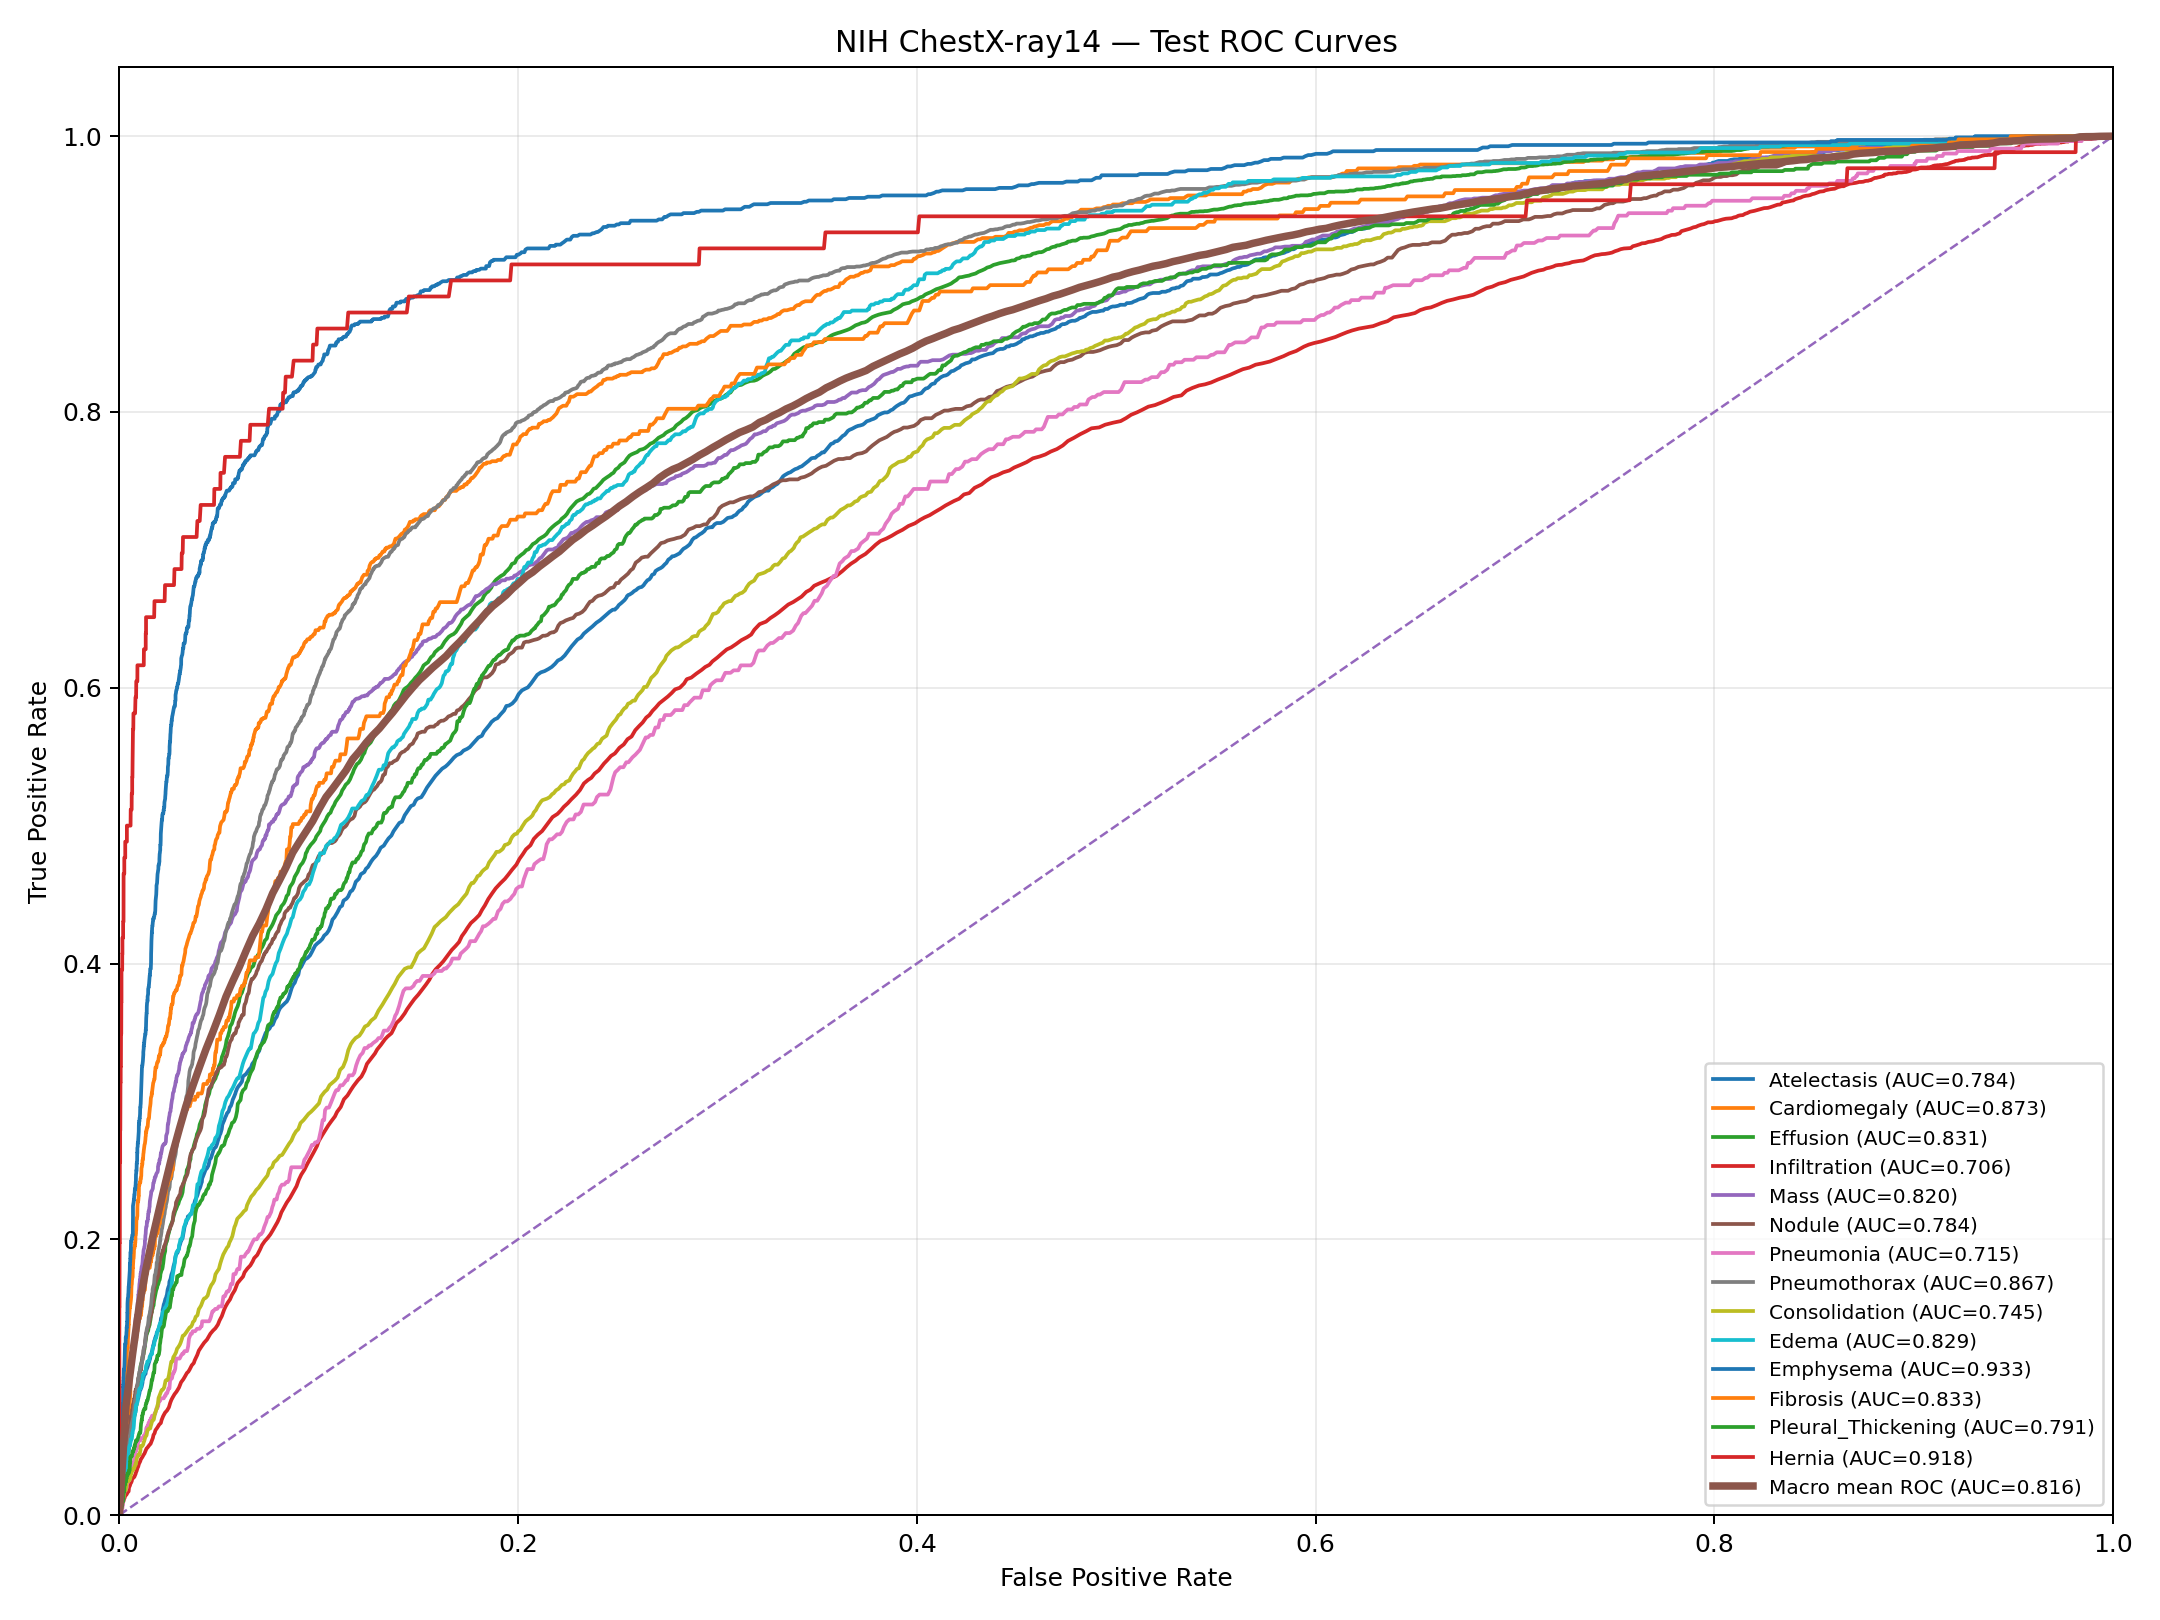

In [13]:
from pathlib import Path
from IPython.display import display, Image as IPImage

out = Path(CONFIG["OUTPUT_DIR"])
print("\nSaved artifacts:")
for p in sorted(out.iterdir()):
    if p.is_file():
        print(f"{p.name:40s} {p.stat().st_size/(1024**2):8.2f} MB")

summary = out / "test_summary.json"
if summary.exists():
    print("\nTest summary:")
    print(summary.read_text())

roc = out / "test_roc_curve.png"
if roc.exists():
    display(IPImage(filename=str(roc)))


## Saved outputs

Everything is saved to `/kaggle/working/chestxray14_densenet121/`.

Key outputs:
- `best_model.pt` — best validation macro-AUROC checkpoint
- `last_model.pt` — last completed epoch
- `best_val_roc_curve.png`
- `test_roc_curve.png`
- `test_class_metrics.csv`
- `test_summary.json`
- `train_class_counts.csv`
- `pos_weights.csv` when `LOSS_NAME="weighted_bce"`
- `config.json` — contains the exact Kaggle dataset paths discovered at runtime
- `train_ddp.py` — exact standalone script launched by `torchrun`

### Controlled ablation
Keep the exact same official test split and patient-level validation split. Compare:
1. `LOSS_NAME="bce"`
2. `LOSS_NAME="weighted_bce"`
3. `LOSS_NAME="asl"`

Track **macro AUROC and macro AUPRC**, plus all 14 per-class metrics in W&B.
